# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>

<div class="alert alert-block alert-success">
<b>Respuesta del revisor V</b> <a class="tocSkip"></a><br>

Hola! Buen trabajo! Veo que en tu notebook ya completaste ambas tareas solicitadas. ✅ 

1. creaste las muestras por usuario añadiendo ceros para los visitantes sin pedidos (sample_zero_a / sample_zero_b) y ejecutaste Mann‑Whitney;
2. y generaste la lista de usuarios anómalos (por número de pedidos y por pedidos caros), filtraste el dataset y repetiste la prueba con las muestras filtradas.

**Como sugerencias prácticas:** verifica que la cantidad de ceros sea exactamente visits_sum - buyers_count (evita off-by-one), y corrige pequeños detalles de impresión / nombres de variables (por ejemplo, usar p_value1 vs p_value) para mantener la trazabilidad. 🚀
</div>


<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>A resolver!</b> ❗ - ¡Excelente trabajo! Tu proyecto es excepcional y has utilizado elementos avanzados para tu entrega. Es digno de admirar. Sin embargo, hay unos pequeños detalles que deben completarse para dar por cerrado tu proyecto. 

¡Espero pronto tus respuestas!    

</div>



<div class="alert alert-block alert-danger">
<b>Respuesta del revisor IV</b> <a class="tocSkip"></a><br>

Hola! Has avanzado grandemente: 

Ejecutaste un z‑test y también un Mann‑Whitney sobre pedidos por usuario, pero solo nos falta ajustar dos cosas clave.
  
1. Primero, la prueba por usuario debe representar a todos los visitantes (incluyendo los que no compraron) —es decir, añade ceros para los visitantes sin pedidos antes de la prueba; Mann‑Whitney acepta muestras de distinto tamaño, pero incluir ceros refleja correctamente la distribución por usuario.
2. Segundo, tu "filtrado" sólo usa el percentil de revenue; además debes excluir usuarios anómalos por número de pedidos (p. ej. >95º percentil).

Recomendación práctica: crea orders_by_user, genera sampleA/sampleB añadiendo ceros (visits_sum - buyers_count) y luego stats.mannwhitneyu(sampleA, sampleB). Después de eso, vuelve a filtrar excluyendo usuarios identificados como anómalos y repite tanto la prueba de conversión como la de AOV. 🚀

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del revisor</b> <a class="tocSkip"></a><br>

Para ayudarte, nuevamente te dejo un snippet claro y práctico que hace 

(1) crear la lista de usuarios anómalos (por número de pedidos y por pedidos caros), 

(2) filtrar el dataset excluyendo esos usuarios y 

(3) ejecutar la prueba de Mann‑Whitney para conversión usando la muestra por usuario (incluyendo ceros para los que no compraron). Pégalo en una celda y ejecútalo; imprime p‑values y diferencias relativas para crudos y filtrados. 🚀

```python
# 1) usuarios anómalos (muchos pedidos + pedidos caros)
orders_by_user = orders.groupby(['visitor_id','group'])['transaction_id'].nunique().reset_index(name='orders')
users_many_orders = orders_by_user[orders_by_user['orders'] > 2]['visitor_id']
price_cutoff = orders['revenue'].quantile(0.95)
users_expensive = orders[orders['revenue'] > price_cutoff]['visitor_id']
abnormal_users = pd.concat([users_many_orders, users_expensive]).drop_duplicates()

# 2) filtrado de orders excluyendo usuarios anómalos
orders_filtered = orders[~orders['visitor_id'].isin(abnormal_users)]

# helper para crear muestras "por usuario" (con ceros) para Mann-Whitney
def make_user_sample(orders_df, visits_df, group_label):
    orders_by_user_g = orders_df[orders_df['group']==group_label].groupby('visitor_id', as_index=False)['transaction_id'].nunique().rename(columns={'transaction_id':'orders'})
    orders_series = orders_by_user_g['orders']
    zeros = pd.Series(0, index=np.arange(visits_df[visits_df['group']==group_label]['visits'].sum() - len(orders_series)), name='orders')
    return pd.concat([orders_series, zeros], axis=0)

# 3) pruebas: crudos y filtrados
sampleA_raw = make_user_sample(orders, visits, 'A')
sampleB_raw = make_user_sample(orders, visits, 'B')
p_raw = stats.mannwhitneyu(sampleA_raw, sampleB_raw)[1]
print(f"P-value (conversión, crudos): {p_raw:.5f}, diff_rel: {sampleB_raw.mean()/sampleA_raw.mean()-1:.3f}")

sampleA_f = make_user_sample(orders_filtered, visits, 'A')
sampleB_f = make_user_sample(orders_filtered, visits, 'B')
p_f = stats.mannwhitneyu(sampleA_f, sampleB_f)[1]
print(f"P-value (conversión, filtrados): {p_f:.5f}, diff_rel: {sampleB_f.mean()/sampleA_f.mean()-1:.3f}")
```
</div>

<div class="alert alert-block alert-danger">
<b>comentario del revisor III</b> <a class="tocSkip"></a><br>

Hola Alberto. Has avanzado mucho, pero no todos los puntos de la lista están completados. ✅  
- **OBLIGATORIO** Graficar tasa de conversión acumulada y AOV acumulado: no encontré la gráfica de conversión acumulada ni la del tamaño de pedido promedio acumulado; sólo hay tasas diarias y acumulado de ingresos/pedidos. Te recomiendo crear conversiones acumuladas como cum_orders/cum_visits y luego plotear por grupo. 📈  
- **OBLIGATORIO** Prueba de conversión por usuario (Mann‑Whitney): actualmente usas un z‑test de proporciones; falta la comparación por usuario (cuentas de pedidos por usuario) con Mann‑Whitney. Puedes obtener ordersByUsersA/B y ejecutar stats.mannwhitneyu(ordersA, ordersB). 🧪  
- **ESTO PODEMOS DEJARLO COMO RECOMENDADO, MAS NO OBLIGATORIO** Dataset filtrado correctamente: filtras pedidos caros por percentil, pero no excluyes explícitamente usuarios anómalos (usuarios con muchas orders). Crea una lista de usuarios anómalos (por percentil de pedidos y por revenue) y exclúyelos antes de recalcular conversiones y AOV. 🔧  

Te muestro un ejemplo corto para avanzar: 

orders_by_user = orders.groupby(['visitor_id','group'])['transaction_id'].nunique().reset_index(name='orders')  
abnormal_users = orders_by_user[orders_by_user['orders']>2]['visitor_id'].unique()  
y luego filtrar orders[~orders['visitor_id'].isin(abnormal_users)]. 🚀
</div>

<div class="alert alert-block alert-info">
<b>Respuesta del revisor</b> <a class="tocSkip"></a><br>

Aca te dejo dos snipets prácticos: uno para graficar la tasa de conversión acumulada y el AOV acumulado por grupo, y otro para ejecutar la prueba de Mann‑Whitney sobre la conversión por usuario (orders por usuario) 👍.

1) Cálculo y plot de conversión acumulada y AOV acumulado (ejemplo):
```python

orders_agg = orders.groupby(['date','group']).agg(orders=('transaction_id','nunique'),
                                                   revenue=('revenue','sum')).reset_index()
visits_agg = visits.groupby(['date','group']).agg(visits=('visits','sum')).reset_index()

cum = orders_agg.merge(visits_agg, on=['date','group'])
cum = cum.sort_values(['group','date'])
cum['cum_orders'] = cum.groupby('group')['orders'].cumsum()
cum['cum_revenue'] = cum.groupby('group')['revenue'].cumsum()
cum['cum_visits'] = cum.groupby('group')['visits'].cumsum()

cum['cum_cr'] = cum['cum_orders'] / cum['cum_visits']
cum['cum_aov'] = cum['cum_revenue'] / cum['cum_orders']

# plot
import matplotlib.dates as mdates
for metric in ['cum_revenue','cum_aov','cum_cr']:
    plt.figure(figsize=(8,4))
    sns.lineplot(data=cum, x='date', y=metric, hue='group')
    plt.title(metric + ' por grupo (acumulado)')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.show()
```

2) Mann‑Whitney para conversión por usuario (uso por‑usuario en lugar de z‑test):
```python
orders_by_user = orders.groupby(['visitor_id','group']).agg(orders=('transaction_id','nunique')).reset_index()

ordersA = orders_by_user[orders_by_user['group']=='A']['orders']
ordersB = orders_by_user[orders_by_user['group']=='B']['orders']

# añadir ceros para usuarios que no hicieron pedidos
zerosA = pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersA)), name='orders')
zerosB = pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersB)), name='orders')

sampleA = pd.concat([ordersA, zerosA], axis=0)
sampleB = pd.concat([ordersB, zerosB], axis=0)

from scipy import stats
p = stats.mannwhitneyu(sampleA, sampleB)[1]
print(f"P-value (Mann-Whitney, por usuario): {p:.5f}")
```

Recomendación: si usas z‑test, explícita por qué (es para proporciones agregadas), pero la prueba por usuario con Mann‑Whitney es la recomendada aquí por la naturaleza no normal y por comparar distribuciones de usuarios. 🚀
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor II</b> <a class="tocSkip"></a><br>

    

<b>A resolver!</b> ❗ - ¡Excelente trabajo, Albert! Tu proyecto es excepcional y has utilizado elementos avanzados para tu entrega. Es digno de admirar. Sin embargo, hay unos pequeños detalles que deben completarse para dar por cerrado tu proyecto. De acuerdo a la anterior revision, no pude encontrar resultas las sugerencias que te he indicado. En las conclusiones, puedes encontrar nuevamente los segmentos marcados como PRIORITARIO que deben completarse. Los marcados como RECOMENDADO no son obligatorios, pero siempre es útil incluirlos en tu análisis. 

¡Espero pronto tus respuestas!    

</div>



</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>¡A resolver</b>! —¡Hola, Albert! (Espero pueda llamarte de esta manera; si no, sino hazmelo saber!). Te comento que has hecho un gran trabajo y te admiro por ello. Me encantaron tus insights y la forma de justificar tus experimentos. Solo faltan unos detalles mínimos para afinar, y así podamos dar por concluida la evaluación.

Más adelante encontrarás mis comentarios y sugerencias. ¡Espero pronto tus respuestas!

</div>

In [1]:
#carga de librerias necesarias para el proyecto 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

# Proyecto 10

#### tineda online (Analisis A/b)
empezamos a cargar DF/BD y corroborar que le tipo de infomraicon sea adecauda para cada accion a realziar.


In [2]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')



In [3]:
hypotheses.columns = hypotheses.columns.str.lower()
print(hypotheses.info())
print(hypotheses.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None
                                          hypothesis  reach  impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   confidence  effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1

In [4]:
orders['date'] = pd.to_datetime(orders['date'], format= '%Y-%m-%d')
orders.columns = orders.columns.str.lower()
orders.rename(columns={
    'transactionid': 'transaction_id',
    'visitorid': 'visitor_id'
}, inplace=True)
print(orders.info())
print(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   float64       
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
None
   transaction_id  visitor_id       date  revenue group
0      3667963787  3312258926 2019-08-15     30.4     B
1      2804400009  3642806036 2019-08-15     15.2     B
2      2961555356  4069496402 2019-08-15     10.2     A
3      3797467345  1196621759 2019-08-15    155.1     B
4      2282983706  2322279887 2019-08-15     40.5     B


In [5]:
visits['date']= pd.to_datetime(visits['date'], format='%Y-%m-%d')
print(visits.info())
print(visits.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
None
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756


se cargaron y limpiaron los datos, 
- df Hypotheses tenia un separador distinto a , y se tuvo que ajustar en al improtancion a ; 
- df Orders se actualizo el campo date a formato datetime para poder hacer las operaciones necesarias.
- df Visits se actualizo el campo date a formato datetime para poder hacer las operaciones necesarias.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - Buen inicio: cargaste correctamente los tres datasets, normalizaste nombres de columnas y convertiste las fechas a datetime, lo que deja los dataframes listos para análisis temporal. Además renombrar transactionid/visitorid facilita la lectura del código. Excelente trabajo en la parte de limpieza inicial. 🚀
    
</div>

# Priorizar hipótesis
### Aplicar el framework ICE/RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.


In [6]:
hypotheses['ice'] = (hypotheses['impact']*hypotheses['confidence'])/ hypotheses['effort']
hypotheses['rice'] = (
    hypotheses['reach']*hypotheses['impact']*hypotheses['confidence']
    )/ hypotheses['effort']


In [7]:
hypotheses_ice = (
    hypotheses[['hypothesis','ice']]
    .sort_values('ice', ascending=False)
    .reset_index(drop=True)
    )
hypotheses_ice['rank_ice'] = hypotheses_ice['ice'].rank(ascending=False, method= 'first')
print(hypotheses_ice)

                                          hypothesis        ice  rank_ice
0  Launch a promotion that gives users discounts ...  16.200000       1.0
1  Add two new channels for attracting traffic. T...  13.333333       2.0
2  Add a subscription form to all the main pages....  11.200000       3.0
3  Show banners with current offers and sales on ...   8.000000       4.0
4  Add product recommendation blocks to the store...   7.000000       5.0
5  Launch your own delivery service. This will sh...   2.000000       6.0
6  Add a customer review page. This will increase...   1.333333       7.0
7  Change the category structure. This will incre...   1.125000       8.0
8  Change the background color on the main page. ...   1.000000       9.0


In [8]:
hypotheses_rice = (
    hypotheses[['hypothesis','rice']]
    .sort_values('rice', ascending=False)
    .reset_index(drop=True)
    )
hypotheses_rice['rank_rice'] = hypotheses_rice['rice'].rank(ascending=False, method= 'first')
print(hypotheses_rice)

                                          hypothesis   rice  rank_rice
0  Add a subscription form to all the main pages....  112.0        1.0
1  Add product recommendation blocks to the store...   56.0        2.0
2  Add two new channels for attracting traffic. T...   40.0        3.0
3  Show banners with current offers and sales on ...   40.0        4.0
4  Launch a promotion that gives users discounts ...   16.2        5.0
5  Change the category structure. This will incre...    9.0        6.0
6  Launch your own delivery service. This will sh...    4.0        7.0
7  Add a customer review page. This will increase...    4.0        8.0
8  Change the background color on the main page. ...    3.0        9.0


In [9]:
hypotheses_vs = hypotheses_ice[['hypothesis', 'rank_ice']].merge(
    hypotheses_rice[['hypothesis', 'rank_rice']],
    on= 'hypothesis',
    how= 'inner'
)
hypotheses_vs['movement'] = (hypotheses_vs['rank_ice']-hypotheses_vs['rank_rice'])

def arrow(m):
    if m > 0:
        return "⏫"
    elif m < 0:
        return "⏬"
    else:
        return "✅"
    
hypotheses_vs['trend'] = hypotheses_vs['movement'].apply(arrow)

print(hypotheses_vs)


                                          hypothesis  rank_ice  rank_rice  \
0  Launch a promotion that gives users discounts ...       1.0        5.0   
1  Add two new channels for attracting traffic. T...       2.0        3.0   
2  Add a subscription form to all the main pages....       3.0        1.0   
3  Show banners with current offers and sales on ...       4.0        4.0   
4  Add product recommendation blocks to the store...       5.0        2.0   
5  Launch your own delivery service. This will sh...       6.0        7.0   
6  Add a customer review page. This will increase...       7.0        8.0   
7  Change the category structure. This will incre...       8.0        6.0   
8  Change the background color on the main page. ...       9.0        9.0   

   movement trend  
0      -4.0     ⏬  
1      -1.0     ⏬  
2       2.0     ⏫  
3       0.0     ✅  
4       3.0     ⏫  
5      -1.0     ⏬  
6      -1.0     ⏬  
7       2.0     ⏫  
8       0.0     ✅  


se aplicaron los metodos de priorizacion a ICE y RICE al df Hypotheses para determinar cuales hipotesis vna a tener un mayor impacto.
analizando los datos a fondo podemos observar que, la propmocion de cumpleaños no cumple con los requerimeintos de alcance, si bien en la metodologia ice salio en los primeros lugares en rice se desploma por el poco alcance uqe se tiene, a diferentua de la hipoteis donde se plantea agregar un foirmato de suscpcion donde el alcance es mayor por lo que en ICE esta en el rank 3 y en RICE en 1.

cuando incluimos el alcance a nuestras hipotesis, aumentan de valor todas aquellas que tengan o atraigan trafico, ya que esta metrica pesa mucho. 

top 3 hipotesis:
-  Add a subscription form to all the main pages. This will help you compile a mailing list
-  Add product recommendation blocks to the store's site. This will increase conversion and average purchase size
-  Show banners with current offers and sales on the main page. This will boost conversion

# Testeo A/B

1.- Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Ingreso acumulado por grupo')

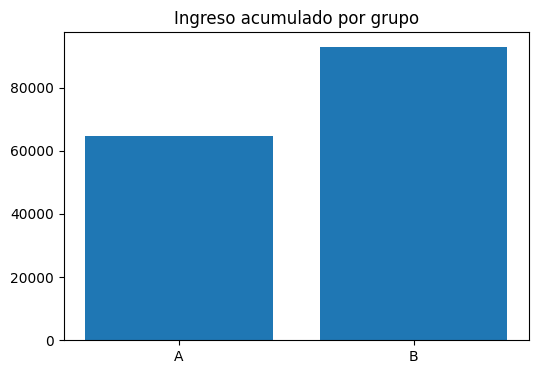

In [10]:
revenue_a = orders[orders['group']== 'A'].copy()
revenue_b = orders[orders['group']== 'B'].copy()
revenue_a_total = revenue_a['revenue'].sum()
revenue_b_total = revenue_b['revenue'].sum()
groups =['A','B']
bar_revenue = [revenue_a_total, revenue_b_total]
plt.figure(figsize=[6,4])
plt.bar(
    groups,
    bar_revenue
)
plt.title('Ingreso acumulado por grupo')

revisando el ingreso acumulado a simple vista podemos observar que el grupo b es quien mas a gastado dentro de nuestras muestras, esta informaiconn es insuficiente para tomar una decision. 

Text(0.5, 0, 'Fecha')

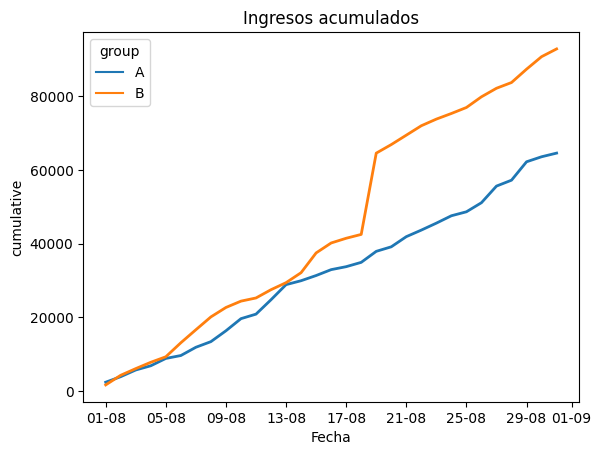

In [11]:
revenue_a_acc = revenue_a.groupby(['group', 'date'])['revenue'].sum().reset_index()
revenue_a_acc['cumulative'] = revenue_a_acc['revenue'].cumsum()
revenue_b_acc = revenue_b.groupby(['group', 'date'])['revenue'].sum().reset_index()
revenue_b_acc['cumulative'] = revenue_b_acc['revenue'].cumsum()
revenue_acc_plot = pd.concat([revenue_a_acc, revenue_b_acc])
sns.lineplot(
    data= revenue_acc_plot,
    x= 'date',
    y= 'cumulative',
    hue= 'group',
    linewidth=2
)
plt.title('Ingresos acumulados')
date_form = mdates.DateFormatter('%d-%m')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xlabel('Fecha')

una vez desglosada la informacion podemos apreciar que ambos grupos tienen un comportamiento similar al inicio, sin emabrgo, el grupo b tuvo un repunto muy abrupto lo cual nos peude indicar que tenememos outliners ya que despues de ese punto se ve que la grafica se mantiene estable.

Text(0.5, 1.0, 'Ingresos por grupos')

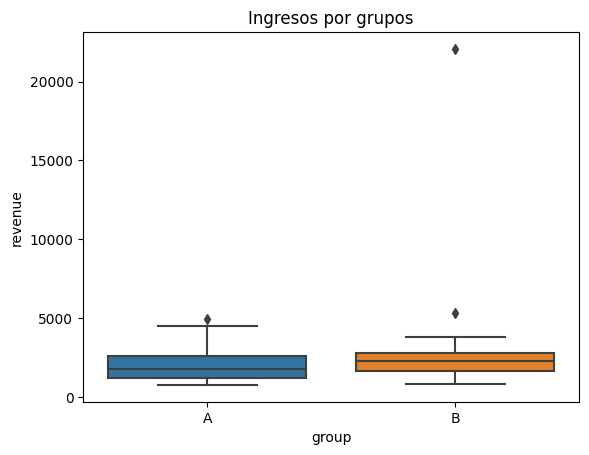

In [12]:
sns.boxplot(
    x='group',
    y='revenue',

    data=revenue_acc_plot
)
plt.title('Ingresos por grupos')


se analizaorn los datos por medio de boxplot para determinar si existian outliners y podemos observar que el grupo b tiene 2 pedidos que inflan las metricas, por lo cual sin esto ambos serian muy similares 

2.- Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Ordenes totales por grupo')

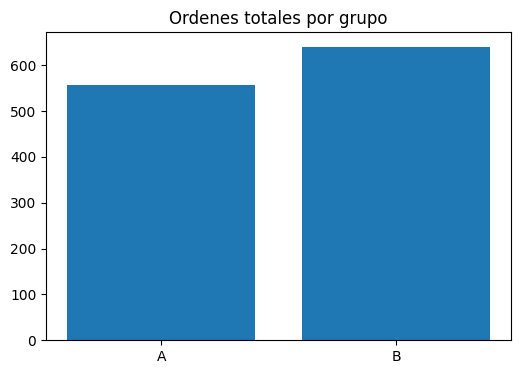

In [13]:
orders_a = orders[orders['group']== 'A'].copy()
orders_b = orders[orders['group']== 'B'].copy()
orders_a_total = orders_a['transaction_id'].count()
orders_b_total = orders_b['transaction_id'].count()
groups =['A','B']
bar_orders = [orders_a_total, orders_b_total]
plt.figure(figsize=[6,4])
plt.bar(
    groups,
    bar_orders
)
plt.title('Ordenes totales por grupo')

Analizando los perdidos podemos observar que en genral el grupo b es quien ams realiza pedidos a comparacion del grupo a

Text(0.5, 0, 'Fecha')

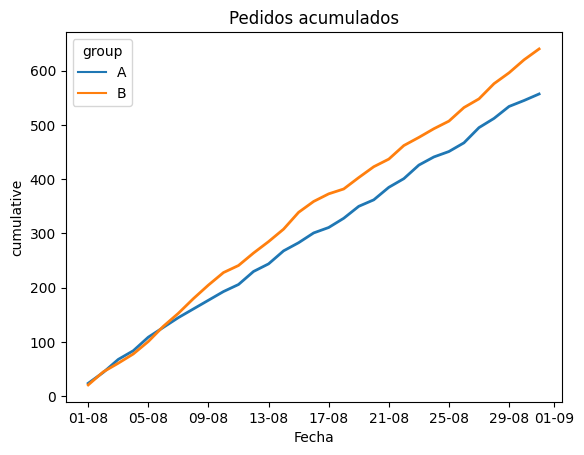

In [14]:
orders_a_acc = orders_a.groupby(['group', 'date'])['transaction_id'].count().reset_index()
orders_a_acc['cumulative'] = orders_a_acc['transaction_id'].cumsum()
orders_b_acc = orders_b.groupby(['group', 'date'])['transaction_id'].count().reset_index()
orders_b_acc['cumulative'] = orders_b_acc['transaction_id'].cumsum()
orders_acc_plot = pd.concat([orders_a_acc, orders_b_acc])
sns.lineplot(
    data= orders_acc_plot,
    x= 'date',
    y= 'cumulative',
    hue= 'group',
    linewidth=2
)
plt.title('Pedidos acumulados')
date_form = mdates.DateFormatter('%d-%m')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xlabel('Fecha')

de igual manera observamos que tenemos una tendencia a la alza estable en ambos grupos sin cambios tan abruptos 

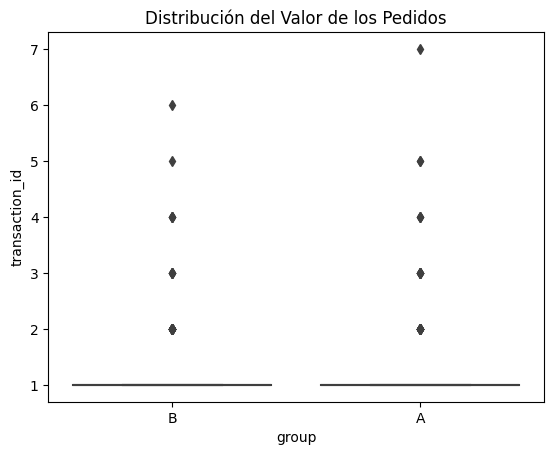

In [15]:
orders_combined = pd.concat([orders_a, orders_b])
orders_per_user = orders_combined.groupby(['visitor_id', 'group'])['transaction_id'].count().reset_index()

sns.boxplot(
    x='group',
    y='transaction_id',
    data=orders_per_user
)
plt.title('Distribución del Valor de los Pedidos')

plt.show()

tratando de anlaizar el comportamiento de los outliners para pedidos si nos encontramos que ambos tienen demasiados outliners, aqui podemos observar que el grupo a es quient tiene mas outliners en contraste con el grupo b.

3.- Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.

In [16]:
aov_a = revenue_a['revenue'].sum() / orders_a['transaction_id'].nunique()
aov_b = revenue_b['revenue'].sum() / orders_b['transaction_id'].nunique()
diff_relative = ((aov_b - aov_a) / aov_a)*100
print(f"La diferencia relativia de ticket promedio entre ambos grupos es {diff_relative:.2f}%")

La diferencia relativia de ticket promedio entre ambos grupos es 25.17%


comparando el valor de ticket promedio podmeos observar que entre ambos grupos tenemos una diferencia de alrededor del 25%, lo representa una diferencia significativa.

4.- Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

count    62.000000
mean      3.290968
std       1.076536
min       1.220000
25%       2.450000
50%       3.255000
75%       4.075000
max       6.230000
Name: cr %, dtype: float64


Text(0.5, 1.0, 'Tasa de conversion')

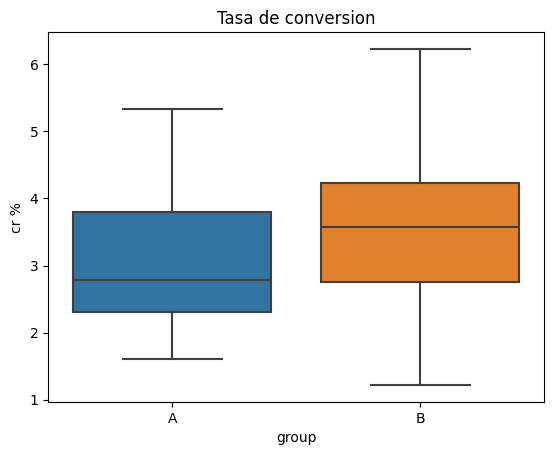

In [17]:

orders_daily = orders.groupby(['date', 'group'])['transaction_id'].nunique().reset_index()
cr = orders_daily.merge(visits, on=['date', 'group'], how= 'right')
cr['orders'] = cr['transaction_id'].fillna(0)
cr['cr'] = cr['transaction_id'] / cr['visits']
cr['cr pct'] = cr['cr'] * 100
cr['cr %'] = cr['cr pct'].apply(lambda x: int(x *100)/100)


cr_pivot = cr.pivot(index='date', columns='group', values='cr')
cr_pivot['diff_rel'] = (cr_pivot['B'] - cr_pivot['A']) / cr_pivot['A']
print(cr['cr %'].describe())

sns.boxplot(
    x= 'group',
    y= 'cr %',
    data= cr    
)
plt.title('Tasa de conversion')


<AxesSubplot:xlabel='date', ylabel='cr_cum'>

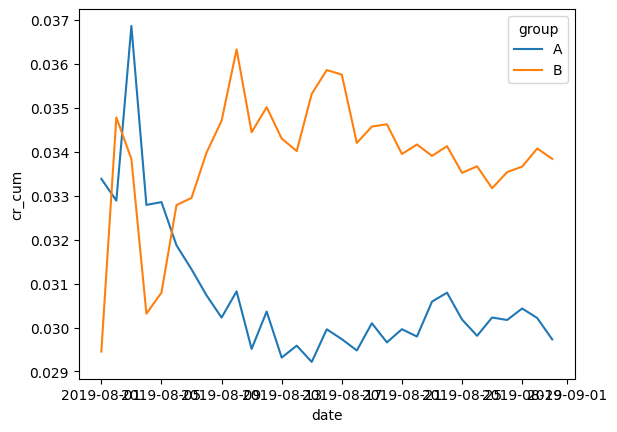

In [18]:
cr = cr.sort_values('date')
cr['orders_cum'] = cr.groupby('group')['transaction_id'].cumsum()
cr['visits_cum'] = cr.groupby('group')['visits'].cumsum()
cr['cr_cum'] = cr['orders_cum'] / cr['visits_cum']

sns.lineplot(
    data=cr,
    x= 'date',
    y= 'cr_cum',
    hue= 'group'
)

revisando la tasa de conversion podemos observar que el diagrama del grupo b es mucho mas amplio, lo cual quiere decir que el grupo b es el que tiene mejores tasas de conversion. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - Calculaste ICE y RICE correctamente y los comparaste de forma clara (rank y tendencia), y las gráficas acumuladas de ingresos y pedidos están bien construidas y muestran la subida abrupta en B coherente con la tabla. La visualización apoya la observación sobre outliers (se ve el salto marcado en B). Como mejora, puedes añadir anotaciones o marcar la fecha del pico para facilitar interpretación rápida en presentaciones. 🔍📈
    
</div>

5.- Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.

      visitor_id group  orders
0        5114589     B       1
1        6958315     B       1
2        8300375     A       1
3        8300375     B       1
4       11685486     A       1
...          ...   ...     ...
1084  4266935830     B       1
1085  4278982564     A       1
1086  4279090005     B       1
1087  4281247801     B       1
1088  4283872382     B       1

[1089 rows x 3 columns]


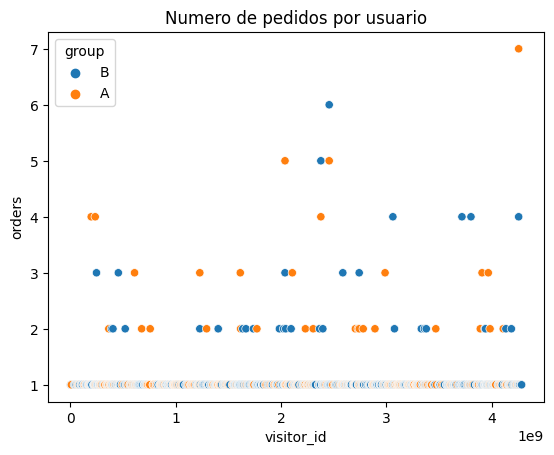

In [19]:
orders_concat = pd.concat([orders_a, orders_b])
orders_per_user = orders_concat.groupby(['visitor_id', 'group']).size().reset_index(name='orders')

sns.scatterplot(data=orders_per_user, x= 'visitor_id', y= 'orders', hue= 'group')
plt.title('Numero de pedidos por usuario')

print(orders_per_user)

se realizo el analiside pedidos, sin embargo, un scatter es ineficiente apra este dataset ya que la amyoria de los usuarios hacen un solo epdido y son pocos los que realizan pedidos con msa frecuencia, podemos observar que un usuario del grupo b es quein ha realizado 7 pedidos. 

para este caso utilizaria mejor un box plot apra poder analizar los outliners mas eficientemente.

6.- Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía

In [20]:
np.percentile(orders_per_user['orders'], 90)
np.percentile(orders_per_user['orders'], 95)
np.percentile(orders_per_user['orders'], 99)

print(f"El 90% de los clientes solo han comprado {np.percentile(orders_per_user['orders'], 90)} o menos productos.")
print(f"El 95% de los clientes compran {np.percentile(orders_per_user['orders'], 95)} o menos productos.")
print(f"El 99% de los cleintes realizan {np.percentile(orders_per_user['orders'], 99)} compras o menos.")


El 90% de los clientes solo han comprado 1.0 o menos productos.
El 95% de los clientes compran 2.0 o menos productos.
El 99% de los cleintes realizan 4.0 compras o menos.


revisando al informaicon podemos identificar que cualqeuir usuario que realice mas de 4 pedidos se debe de conciderar un outliner, a los cuales les podriamos llamar cleintes VIP.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - El scatter de pedidos por usuario muestra la dispersión pero es poco práctico aquí (es decir, muchos puntos superpuestos); tu observación de preferir boxplot es correcta. Calculaste percentiles 90/95/99 correctamente; sin embargo decidiste etiquetar >4 pedidos como outlier (un poco conservador). Está bien si lo justificas, pero documenta por qué eliges ese umbral. Añade también un conteo de usuarios afectados por ese corte. 📊
    
</div>

7.- Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Distribucion de precios por usuario')

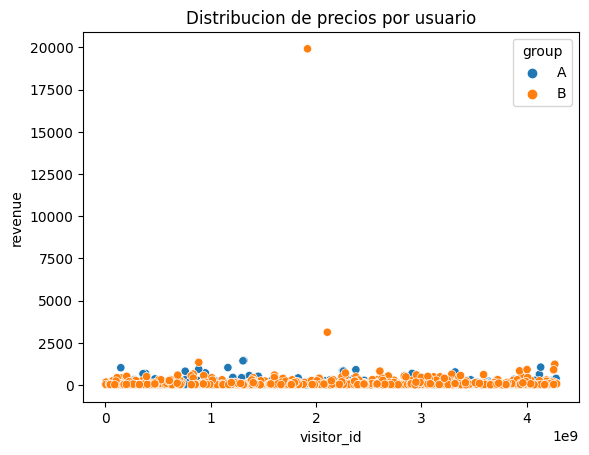

In [21]:
sns.scatterplot(data=orders_concat, x= 'visitor_id', y='revenue', hue='group')
plt.title('Distribucion de precios por usuario')


Text(0.5, 1.0, 'Distribucion de precios por fecha')

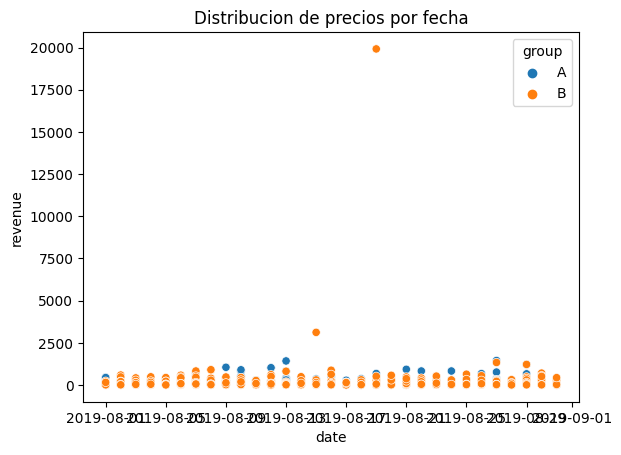

In [22]:
sns.scatterplot(data= orders_concat, x= 'date', y= 'revenue', hue= 'group')
plt.title('Distribucion de precios por fecha')

revisamos la distribucinion de reveneu por usuario y pdemos observar que los usuraios del grupo b tienen outliners, lo cual significa uqe los usuarios del grupo b gastan mas. 

si analizamos la distribucion por fecha podemos observar una distribucion similar, lo cual confimra que que el grupo b es el mas activo.

8.- Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [23]:
print(f"El 90% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 90):.2f} o menos.")
print(f"El 95% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 95):.2f} o menos.")
print(f"El 99% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 99):.2f} o menos.")


El 90% del valor de los pedidos es de $282.48 o menos.
El 95% del valor de los pedidos es de $435.54 o menos.
El 99% del valor de los pedidos es de $900.90 o menos.


9.- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

H0= no existe diferencia entre la tasa de conversion entre el grupo a y grupo b.
H1= existe una diferencia significativa entre la tasa de conversio de los grupos a y b.

In [24]:
visits_daily = visits.groupby(['date', 'group'])['visits'].sum().reset_index()

print(visits_daily)

         date group  visits
0  2019-08-01     A     719
1  2019-08-01     B     713
2  2019-08-02     A     619
3  2019-08-02     B     581
4  2019-08-03     A     507
..        ...   ...     ...
57 2019-08-29     B     531
58 2019-08-30     A     490
59 2019-08-30     B     490
60 2019-08-31     A     699
61 2019-08-31     B     718

[62 rows x 3 columns]


In [25]:
z_orders_a = orders_concat[orders_concat['group']=='A']['transaction_id'].count()
z_orders_b = orders_concat[orders_concat['group']=='B']['transaction_id'].count()
z_visits_a = visits_daily[visits_daily['group'] == 'A']['visits'].sum()
z_visits_b = visits_daily[visits_daily['group'] == 'B']['visits'].sum()

z_stats, p_value1 = proportions_ztest([z_orders_a, z_orders_b], [z_visits_a, z_visits_b])
conversion_a = z_orders_a / z_visits_a
conversion_b = z_orders_b / z_visits_b
relative_diference = ((conversion_b / conversion_a)-1)*100
alpha = 0.05

if p_value1 < alpha:
    print("Decision: 1. Parar la prueba. El grupo B es el líder indiscutible (H1).")
else:
    print("Decision: 2. No hay diferencia significativa todavía (H0).")
print(f"P-value: {(p_value):.4f}")
print(f"Diferenvia relativa {relative_diference:.2f}%")

Decision: 1. Parar la prueba. El grupo B es el líder indiscutible (H1).
P-value: 0.0232
Diferenvia relativa 13.81%


In [26]:


orders_by_users = (
    orders
    .groupby(['visitor_id', 'group'])['transaction_id']
    .nunique()
    .reset_index(name= 'orders')
)

orders_cutoff = orders_by_users['orders'].quantile(.95)

users_many_orders = orders_by_users[
    orders_by_users['orders'] > orders_cutoff
]['visitor_id']

revenue_cutoff = orders['revenue'].quantile(.95)

user_expensive = orders[
    orders['revenue'] > revenue_cutoff
]['visitor_id']

abnormal_users = pd.concat(
    [users_many_orders, user_expensive]
).drop_duplicates()




In [38]:


visits_by_group = visits.groupby('group')['visits'].sum()

orders_by_users_a = orders_by_users[orders_by_users['group'] == 'A']['orders']
orders_by_users_b = orders_by_users[orders_by_users['group'] == 'B']['orders']

zero_visits_a = visits_by_group['A'] - orders_by_users_a.count()
zero_visits_b = visits_by_group['B'] - orders_by_users_b.count()

sample_zero_a = pd.concat([orders_by_users_a, pd.Series([0] * zero_visits_a)])
sample_zero_b = pd.concat([orders_by_users_b, pd.Series([0] * zero_visits_b)])

mean_zero_sample_a = sample_zero_a.mean()
mean_zero_sample_b = sample_zero_b.mean()
relative_diff = (mean_zero_sample_b / mean_zero_sample_a)

u_stat, p_value2 = stats.mannwhitneyu(
    sample_zero_a,
    sample_zero_b
)

alpha= .05
if p_value2 < alpha:
    print("Conclusión: Existe diferencia significativa en la conversión por usuario (H1).")
else:
    print("Conclusión: No se detecta diferencia significativa en la conversión por usuario (H0).")

print(f"P-value: {p_value2:.4f}")
print(f'Diferencia relativa: {relative_diff:.2f}%')



Conclusión: Existe diferencia significativa en la conversión por usuario (H1).
P-value: 0.0168
Diferencia relativa: 1.14%


In [36]:

orders_filtered = orders[~orders['visitor_id'].isin(abnormal_users)]
visits_filtered = visits.copy()

orders_by_users_filtered = (
   orders_filtered
    .groupby(['visitor_id', 'group'])['transaction_id']
    .nunique()
    .reset_index(name='orders')   
)

orders_filtered_a = orders_by_users_filtered[orders_by_users_filtered['group'] == 'A']['orders']
orders_filtered_b = orders_by_users_filtered[orders_by_users_filtered['group'] == 'B']['orders']

visits_by_group = visits.groupby('group')['visits'].sum()

zero_visits_a = visits_by_group['A'] - orders_filtered_a.count()
zero_visits_b = visits_by_group['B'] - orders_filtered_b.count()

filtered_sample_a = pd.concat([orders_filtered_a, pd.Series([0] * zero_visits_a)])
filtered_sample_b = pd.concat([orders_filtered_b, pd.Series([0] * zero_visits_b)])

u_stat, p_value3 = stats.mannwhitneyu(
    filtered_sample_a, 
    filtered_sample_b
)

filtered_mean_a = filtered_sample_a.mean()
filtered_mean_b = filtered_sample_b.mean()
relative_difference = (filtered_mean_b / filtered_mean_a)

if p_value3 < alpha:
    print(
        'Parar la prueba. Existe una diferenica significativa entre al covnersion por usuario'
    )
else: 
    print(
        'No se detectan diferencias significativas'
    )

print(f'P-value: {p_value3:.4f}')
print(f'Diferencia relativa: {relative_difference:.2f}%')

Parar la prueba. Existe una diferenica significativa entre al covnersion por usuario
P-value: 0.0131
Diferencia relativa: 1.17%


para este punto se realizaron 3 pruebas;
- Z-test, para conversion agregada.
- Mann-Whitney, de todos los usuarios incluyendo sin pedidos.
- Mann-Whitney, excluyendo usuarios atipicos.

revisando los resultados podemos observar una diferencia significativa entre los grupos a y b. 

para este punto se decide parar la prueba ya que existe un mejor desempeño del grupo b.

10.- Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

H0= el ticket promedio (AOV) es igual en ambos grupos.

H1= el ticket promedio (AOV) del grupo a es diferente al grupo b.

In [29]:
revenue_a_test = revenue_a['revenue']
revenue_b_test = revenue_b['revenue'] 

revenue_a_mean = revenue_a_test.mean()
revenue_b_mean = revenue_b_test.mean()

revenue_mean = ((revenue_b_mean / revenue_a_mean)-1)*100

m_stats, pvalue = stats.mannwhitneyu(revenue_a_test, revenue_b_test)

if pvalue < alpha:
    print("Decision: 1. Parar la prueba. Hay diferencia significativa en el ticket promedio (H1).")
else:
    print("Decision: 2. Parar la prueba. No hay diferencia significativa en el ticket promedio (H0).")
print(f"P-value: {(pvalue):.2f}")
print(f"Diferenvia relativa {revenue_mean:.2f}%")

Decision: 2. Parar la prueba. No hay diferencia significativa en el ticket promedio (H0).
P-value: 0.69
Diferenvia relativa 25.17%


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ -Detectaste correctamente outliers altos en revenue y lo ilustraste con scatter por usuario/fecha; los percentiles coinciden con lo esperado. Las pruebas estadísticas están realizadas y los resultados son coherentes con las gráficas (conversión significativa, AOV no significativo). Un punto a mejorar: para la comparación de conversión es más consistente usar la aproximación por usuario (Mann‑Whitney sobre pedidos por usuario) por lo que te motivo a investigar sobre ella. O bien, justificar claramente el uso del z-test de proporciones. Además indica explícitamente las fechas/IDs de los outliers para trazabilidad. 🔁
    
</div>

11.- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

H0= la conversion de clientes es igual en ambos grupos.

H1= la conversion entre el grupo a y b es diferente.

In [30]:
outliners = orders['revenue'].quantile(.95)

orders_filtered = orders[orders['revenue'] < outliners]

orders_filtered_a = orders_filtered[orders_filtered['group']== 'A']['revenue']
orders_filtered_b = orders_filtered[orders_filtered['group']== 'B']['revenue']

In [31]:



visitors_a = visits[visits['group'] == 'A']['visits'].sum()
visitors_b = visits[visits['group'] == 'B']['visits'].sum()

filtered_cr_orders_a = orders_filtered[orders_filtered['group'] == 'A']['transaction_id'].nunique()
filtered_cr_orders_b = orders_filtered[orders_filtered['group'] == 'B']['transaction_id'].nunique()

cr_a = filtered_cr_orders_a / visitors_a
cr_b = filtered_cr_orders_b / visitors_b

cr_difference = ((cr_b / cr_a)-1) * 100

cr_stats, cr_pvalue = proportions_ztest([filtered_cr_orders_a, filtered_cr_orders_b], [visitors_a, visitors_b])

if cr_pvalue < alpha:
    print("Decision: 1. Parar la prueba. Hay diferencia significativa en la conversión (H1).")
else:
    print("Decision: 2. Parar la prueba. No hay diferencia significativa en la conversión (H0).")
print(f"P-value: {((cr_pvalue)*100):.2f}%")

print(f"Diferenvia relativa {cr_difference:.2f}%")




Decision: 1. Parar la prueba. Hay diferencia significativa en la conversión (H1).
P-value: 3.62%
Diferenvia relativa 13.04%


12.- Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [32]:
mean_filtered_a = orders_filtered[orders_filtered['group']== 'A']['revenue'].mean()
mean_filtered_b = orders_filtered[orders_filtered['group']== 'B']['revenue'].mean()

aov_difference = ((mean_filtered_b / mean_filtered_a)-1)*100

aov_stats, aov_pvalue = stats.mannwhitneyu(orders_filtered_a, orders_filtered_b)
alpha = .05

if aov_pvalue < alpha:
    print("Conclusión: Rechazamos H0. Hay diferencia significativa entre A y B.")
else:
    print("Conclusión: No podemos rechazar H0. Los grupos son iguales estadísticamente.")



Conclusión: No podemos rechazar H0. Los grupos son iguales estadísticamente.


13.- Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son:
 1. Parar la prueba, considerar a uno de los grupos como líder. 
 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 
 3. Continuar la prueba.

analizamos la ifnormacion completa de este caso, debemos de tomar la opcion 2, concluimos que no ahy diferencia entre los grupos, ya que la informaicon obtenida muestra que peude ser producto del azar. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Aquí hay una inconsistencia importante: en la sección "filtrada" defines outliers por cuantiles pero no parece que hayas excluido esos usuarios al recalcular la conversión (usaste orders_a/orders_b sin filtrar). Además la decisión final indica "no hay diferencia" aunque tus pruebas crudas y filtradas mostraban conversión significativa a favor de B. Corrige calculando orders por usuario sin los usuarios anómalos (o excluyendo pedidos caros) antes de rehacer la prueba de conversión; luego revisa la decisión final con esos resultados. 🔧
    
</div>

### Conclusiones y recomendaciones

- Nivel general: en conjunto, este trabajo se sitúa más en un nivel básico con elementos que apuntan a intermedio, tienes buen manejo de dataframes, ICE/RICE y visualizaciones, pero faltan algunos pasos clave para cerrar el análisis. 🚀  
- Fortalezas:  
  - ✅ Cargas, limpieza y normalización de columnas están bien hechas; el dataset queda listo para análisis.  
  - ✅ Cálculo correcto de ICE y RICE y comparación clara entre ambos (rank y tendencia).  
  - ✅ Detectaste y visualizaste outliers; calculaste percentiles y ejecutaste pruebas estadísticas (AOV y algunos tests).  
- Áreas prioritarias a mejorar / completar:  
  - ⚠️ **RECOMENDADO** Toma en cuenta que faltó graficar la tasa de conversión acumulada y el tamaño de pedido promedio acumulado por grupo (estas gráficas son clave para evaluar estabilidad).  
  - ⚠️ **PRIORITARIO** Repite la prueba de conversión usando la muestra por usuario (Mann‑Whitney) o justifica técnicamente el uso del z‑test; ahora usaste el z‑test pero no hiciste la comparación por usuario.  
  - ⚠️ **PRIORITARIO** Asegúrate de crear correctamente el dataset "filtrado" sin anomalías (excluir usuarios anómalos, no sólo filas de pedidos caros) antes de comparar crudos vs filtrados; hay una inconsistencia en el filtrado actual.

- Siguiente que te sugerido: corrige el filtrado de anomalías, genera las gráficas acumuladas faltantes y rehace las pruebas de conversión por usuario; con eso podrás tomar una decisión final bien fundamentada y subirías tu trabajo a un nivel intermedio. ¡Vas por buen camino, sigue así! 💪📊